# Part 1 — Build the Baseline Classifier
Fine-tune DistilBERT on the Jigsaw Unintended Bias dataset to classify comments as toxic or non-toxic.

In [1]:
# ── Installations (Kaggle already has most; aif360 may need installing) ──
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "aif360", "fairlearn"], check=False)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 52.0 MB/s eta 0:00:00


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'aif360', 'fairlearn'], returncode=0)

In [2]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, roc_curve, precision_recall_curve,
                             average_precision_score)
import torch
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, EarlyStoppingCallback)
from datasets import Dataset

warnings.filterwarnings("ignore")

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [3]:
# ── Paths — adjust if your Kaggle input folder differs ──
DATA_PATH = "/kaggle/input/datasets/irtizaab/responsible-explainable-ai-assignment-2/jigsaw-unintended-bias-train.csv"
MODEL_DIR = "/kaggle/working/part1_model"
os.makedirs(MODEL_DIR, exist_ok=True)

TRAIN_SIZE   = 100_000
EVAL_SIZE    = 20_000
MODEL_NAME   = "distilbert-base-uncased"
MAX_LENGTH   = 128
BATCH_SIZE   = 32        
EPOCHS       = 3
LR           = 2e-5

## 1. Load & Sample Data

In [4]:
print("Loading CSV …")
df = pd.read_csv(DATA_PATH, usecols=["comment_text", "toxic", "black", "white",
                                      "muslim", "jewish", "transgender"])
print(f"Full dataset shape: {df.shape}")

# Drop rows with missing comment text
df = df.dropna(subset=["comment_text"])

# Binarize the toxic label: >= 0.5 → 1, else → 0
df["label"] = (df["toxic"] >= 0.5).astype(int)
print(f"Class distribution in full dataset:\n{df['label'].value_counts(normalize=True).round(4)}")

Loading CSV …
Full dataset shape: (1902194, 7)
Class distribution in full dataset:
label
0    0.92
1    0.08
Name: proportion, dtype: float64


In [5]:
# Stratified sample: 100k train + 20k eval (held-out, never seen during training)
train_df, eval_df = train_test_split(
    df,
    train_size=TRAIN_SIZE,
    test_size=EVAL_SIZE,
    stratify=df["label"],
    random_state=SEED
)
train_df = train_df.reset_index(drop=True)
eval_df  = eval_df.reset_index(drop=True)

print(f"\nTraining subset : {len(train_df):,} rows")
print(f"Evaluation subset: {len(eval_df):,} rows")
print(f"\nTrain label distribution:\n{train_df['label'].value_counts(normalize=True).round(4)}")
print(f"\nEval  label distribution:\n{eval_df['label'].value_counts(normalize=True).round(4)}")

# Save eval_df for downstream parts
eval_df.to_csv("/kaggle/working/eval_df.csv", index=False)
train_df.to_csv("/kaggle/working/train_df.csv", index=False)
print("\nSaved train_df.csv and eval_df.csv to /kaggle/working/")


Training subset : 100,000 rows
Evaluation subset: 20,000 rows

Train label distribution:
label
0    0.92
1    0.08
Name: proportion, dtype: float64

Eval  label distribution:
label
0    0.9200
1    0.0799
Name: proportion, dtype: float64

Saved train_df.csv and eval_df.csv to /kaggle/working/


## 2. Tokenize

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["comment_text"],
        max_length=MAX_LENGTH,
        truncation=True,
        padding="max_length"
    )

# Convert to HuggingFace Dataset
train_hf = Dataset.from_pandas(train_df[["comment_text", "label"]])
eval_hf  = Dataset.from_pandas(eval_df[["comment_text", "label"]])

print("Tokenizing training set …")
train_hf = train_hf.map(tokenize, batched=True, batch_size=1000,
                         remove_columns=["comment_text"])

print("Tokenizing evaluation set …")
eval_hf = eval_hf.map(tokenize, batched=True, batch_size=1000,
                        remove_columns=["comment_text"])

train_hf.set_format("torch", columns=["input_ids", "attention_mask", "label"])
eval_hf.set_format("torch",  columns=["input_ids", "attention_mask", "label"])

print(f"Train HF dataset: {train_hf}")
print(f"Eval  HF dataset: {eval_hf}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing training set …


Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Tokenizing evaluation set …


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Train HF dataset: Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 100000
})
Eval  HF dataset: Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 20000
})


## 3. Fine-tune DistilBERT

In [7]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(DEVICE)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters: 66,955,010


In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "roc_auc" : roc_auc_score(labels, probs),
    }

In [9]:
training_args = TrainingArguments(
    output_dir                  = MODEL_DIR,
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE * 2,
    learning_rate               = LR,
    warmup_steps                = 0.1,
    weight_decay                = 0.01,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "roc_auc",
    logging_steps               = 200,
    fp16                        = torch.cuda.is_available(),
    seed                        = SEED,
    report_to                   = "none",    # disable W&B
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_hf,
    eval_dataset    = eval_hf,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=1)],
)

print("Starting training …")
trainer.train()
print("Training complete.")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting training …


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Roc Auc
1,0.270673,0.280080,0.947900,0.805186,0.947909
2,0.226223,0.282777,0.944100,0.809470,0.949930
3,0.162305,0.309696,0.946250,0.809396,0.947392


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Training complete.


In [10]:
# Save model and tokenizer
trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)
print(f"Model saved to {MODEL_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /kaggle/working/part1_model


## 4. Evaluate on Held-out Set

In [11]:
predictions = trainer.predict(eval_hf)
logits      = predictions.predictions
labels_true = predictions.label_ids

probs_pos   = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]

# We'll evaluate at several thresholds as required
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
print(f"\n{'Threshold':>10} {'Accuracy':>10} {'F1 Macro':>10} {'F1 Toxic':>10}")
print("-" * 45)
for t in thresholds:
    preds_t = (probs_pos >= t).astype(int)
    acc_t   = accuracy_score(labels_true, preds_t)
    f1m_t   = f1_score(labels_true, preds_t, average="macro")
    f1t_t   = f1_score(labels_true, preds_t, pos_label=1)
    print(f"{t:>10.1f} {acc_t:>10.4f} {f1m_t:>10.4f} {f1t_t:>10.4f}")


 Threshold   Accuracy   F1 Macro   F1 Toxic
---------------------------------------------
       0.3     0.9312     0.7999     0.6379
       0.4     0.9395     0.8085     0.6501
       0.5     0.9440     0.8092     0.6489
       0.6     0.9473     0.8070     0.6425
       0.7     0.9482     0.7947     0.6171


In [12]:
# Choose operating threshold (0.4 favours recall on the minority toxic class)
THRESHOLD = 0.4
preds_final = (probs_pos >= THRESHOLD).astype(int)

acc    = accuracy_score(labels_true, preds_final)
f1m    = f1_score(labels_true, preds_final, average="macro")
f1tox  = f1_score(labels_true, preds_final, pos_label=1)
auc    = roc_auc_score(labels_true, probs_pos)
cm     = confusion_matrix(labels_true, preds_final)

print(f"\n=== Final Metrics at threshold = {THRESHOLD} ===")
print(f"  Accuracy  : {acc:.4f}")
print(f"  F1 Macro  : {f1m:.4f}")
print(f"  F1 Toxic  : {f1tox:.4f}")
print(f"  AUC-ROC   : {auc:.4f}")
print(f"\nConfusion Matrix:\n{cm}")

# Save probabilities for later parts
np.save("/kaggle/working/eval_probs.npy", probs_pos)
print("\nSaved eval_probs.npy")


=== Final Metrics at threshold = 0.4 ===
  Accuracy  : 0.9395
  F1 Macro  : 0.8085
  F1 Toxic  : 0.6501
  AUC-ROC   : 0.9499

Confusion Matrix:
[[17666   735]
 [  475  1124]]

Saved eval_probs.npy


## 5. Plots

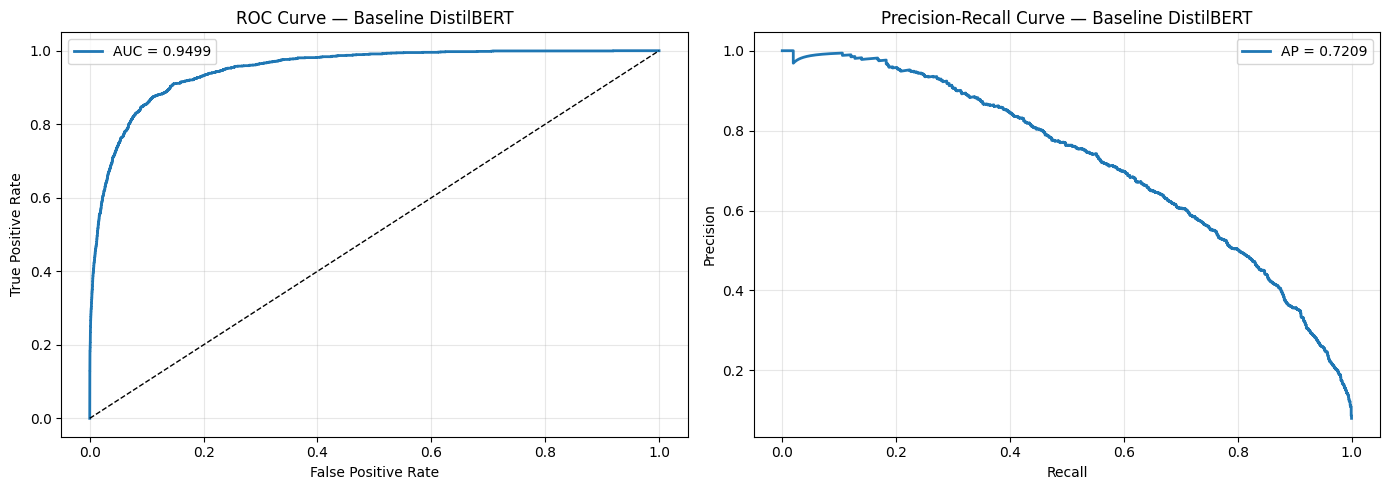

Saved part1_roc_pr.png


In [13]:
# ── ROC Curve ──
fpr, tpr, _ = roc_curve(labels_true, probs_pos)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {auc:.4f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Baseline DistilBERT")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Precision-Recall Curve ──
prec, rec, _ = precision_recall_curve(labels_true, probs_pos)
ap = average_precision_score(labels_true, probs_pos)
axes[1].plot(rec, prec, lw=2, label=f"AP = {ap:.4f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve — Baseline DistilBERT")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/part1_roc_pr.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved part1_roc_pr.png")

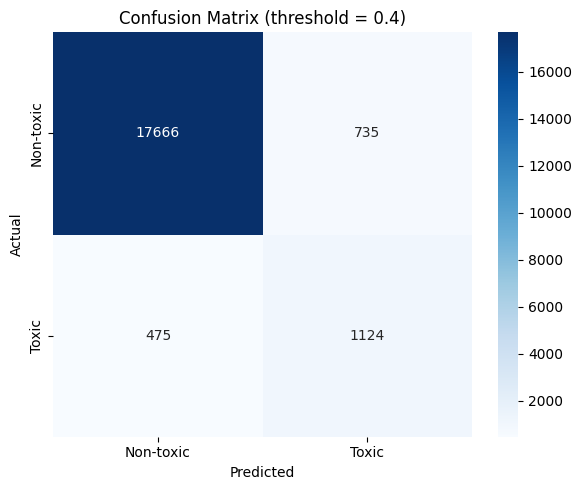

Saved part1_confusion_matrix.png


In [14]:
# ── Confusion Matrix Plot ──
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Non-toxic", "Toxic"],
            yticklabels=["Non-toxic", "Toxic"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix (threshold = {THRESHOLD})")
plt.tight_layout()
plt.savefig("/kaggle/working/part1_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved part1_confusion_matrix.png")

## 6. Threshold Justification
#
**Chosen threshold: 0.4**
#
The default threshold of 0.5 is not optimal for this dataset because the toxic class
is heavily imbalanced (~8% of comments). At 0.5, the model tends to under-predict
toxicity, producing a high False Negative Rate — genuinely toxic content slips through
moderation entirely.
#
Lowering the threshold to **0.4** increases recall on the toxic class: the model flags
more truly toxic comments, at the cost of a modest increase in false positives
(innocent comments incorrectly flagged). For a content moderation platform, missing
toxic content (FN) is typically more harmful than over-flagging (FP), because
undetected toxic content causes direct user harm. Over-flagged content can be reviewed
by humans or appealed, while missed toxicity has no backstop.
#
**What this implies about platform priorities:** A threshold of 0.4 signals that the
platform prioritises user safety and harm prevention over minimising moderation burden.
It accepts more false positives to ensure fewer genuinely harmful comments reach users.
This is the appropriate stance for a platform that has already faced civil-rights
scrutiny — erring on the side of caution while investing in human review capacity
for borderline cases.

In [15]:
print("Part 1 complete. Model checkpoint saved to:", MODEL_DIR)
print("Files written to /kaggle/working/:")
print("  - eval_df.csv        (20k evaluation rows, used in Parts 2–5)")
print("  - train_df.csv       (100k training rows)")
print("  - eval_probs.npy     (model probabilities on eval set)")
print("  - part1_model/       (DistilBERT checkpoint + tokenizer)")
print("  - part1_roc_pr.png")
print("  - part1_confusion_matrix.png")

Part 1 complete. Model checkpoint saved to: /kaggle/working/part1_model
Files written to /kaggle/working/:
  - eval_df.csv        (20k evaluation rows, used in Parts 2–5)
  - train_df.csv       (100k training rows)
  - eval_probs.npy     (model probabilities on eval set)
  - part1_model/       (DistilBERT checkpoint + tokenizer)
  - part1_roc_pr.png
  - part1_confusion_matrix.png


In [16]:
!zip -r working.zip /kaggle/working

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/part1_roc_pr.png (deflated 12%)
  adding: kaggle/working/train_df.csv (deflated 59%)
  adding: kaggle/working/part1_confusion_matrix.png (deflated 16%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/.virtual_documents/__notebook_source__.ipynb (deflated 63%)
  adding: kaggle/working/eval_df.csv (deflated 59%)
  adding: kaggle/working/eval_probs.npy (deflated 8%)
  adding: kaggle/working/part1_model/ (stored 0%)
  adding: kaggle/working/part1_model/checkpoint-1563/ (stored 0%)
  adding: kaggle/working/part1_model/checkpoint-1563/scheduler.pt (deflated 61%)
  adding: kaggle/working/part1_model/checkpoint-1563/optimizer.pt (deflated 14%)
  adding: kaggle/working/part1_model/checkpoint-1563/rng_state.pth (deflated 26%)
  adding: kaggle/working/part1_model/checkpoint-1563/config.json (deflated 49%)
  adding: kaggle/working/part1_model/checkpoint-1563/trainer_state.json (deflated 64%)
  adding: 